# Day 2: From Filters to CNNs

**COMP 395 — Deep Learning**

In this lab, you will:
1. Load and visualize an RGB image as a 3-channel PyTorch tensor
2. Implement max pooling from scratch
3. Use `nn.Conv2d` and visualize what its filters do
4. Build a complete CNN class using `nn.Module`
5. Trace tensor shapes through your network

**Paired work.** Switch driver/navigator at Part 3.

---

## Part 0: Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from skimage import data

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## Part 1: RGB Images as Tensors

### 1.1 Loading a color image

An RGB image has three channels: Red, Green, and Blue. Each channel is a grayscale image showing the intensity of that color.

NumPy shape (H, W, C): (512, 512, 3)
Value range: [0, 255]


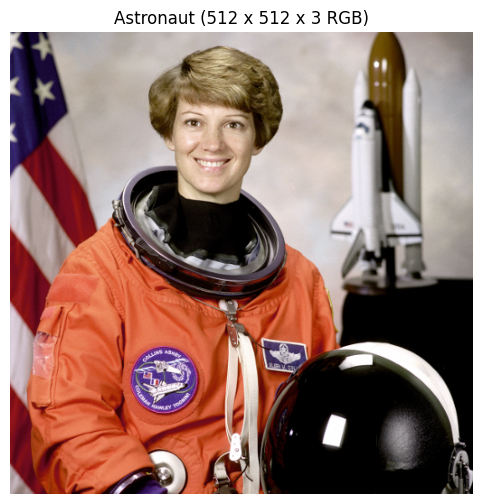

In [11]:
# Load a color test image
rgb_image = data.astronaut()  # shape: (512, 512, 3), values 0-255
print(f"NumPy shape (H, W, C): {rgb_image.shape}")
print(f"Value range: [{rgb_image.min()}, {rgb_image.max()}]")

plt.imshow(rgb_image)
plt.title("Astronaut (512 x 512 x 3 RGB)")
plt.axis('off')
plt.show()

### 1.2 Visualizing the three channels

Each channel is just a grayscale image — the same kind of 2D array you convolved yesterday.

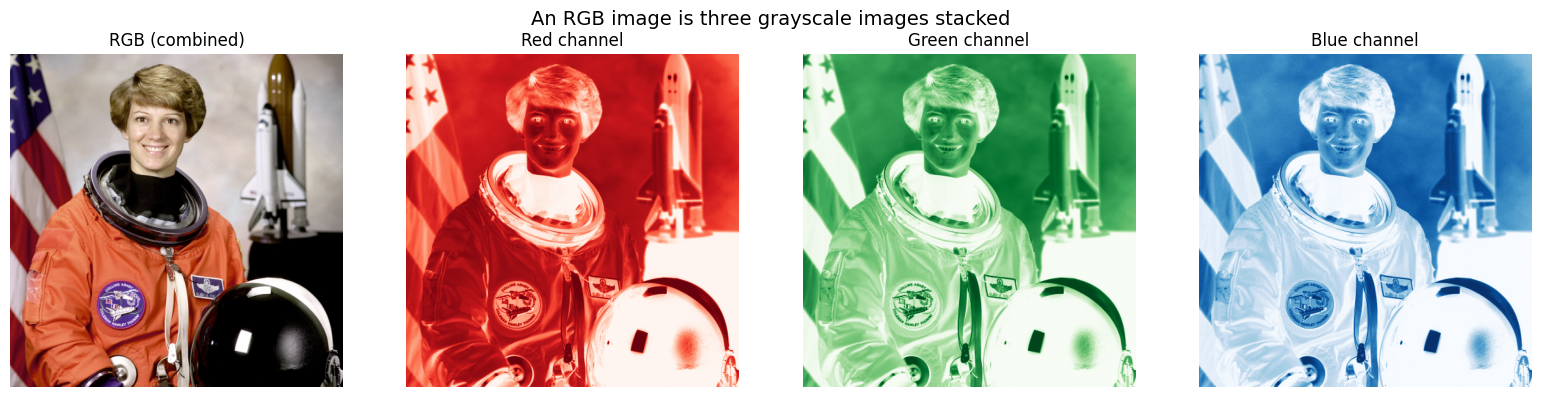

Red channel shape: (512, 512)
Each channel is a 2D array — same as what you convolved yesterday!


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Full color image
axes[0].imshow(rgb_image)
axes[0].set_title("RGB (combined)")
axes[0].axis('off')

# Individual channels
channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

for i in range(3):
    axes[i+1].imshow(rgb_image[:, :, i], cmap=cmaps[i])
    axes[i+1].set_title(f"{channel_names[i]} channel")
    axes[i+1].axis('off')

plt.suptitle("An RGB image is three grayscale images stacked", fontsize=14)
plt.tight_layout()
plt.show()

# Show the shape of one channel
print(f"Red channel shape: {rgb_image[:,:,0].shape}")
print(f"Each channel is a 2D array — same as what you convolved yesterday!")

### 1.3 Converting to PyTorch format

**Critical convention difference:**
- NumPy / PIL: `(H, W, C)` — channels last
- PyTorch: `(C, H, W)` — channels first

This will cause bugs if you forget it. Let's practice the conversion.

In [13]:
# Convert to float32 and normalize to [0, 1]
img_np = rgb_image.astype(np.float32) / 255.0
print(f"NumPy shape (H, W, C): {img_np.shape}")

# Convert to PyTorch tensor
img_tensor = torch.from_numpy(img_np)
print(f"Tensor shape before permute: {img_tensor.shape}")

# Rearrange from (H, W, C) to (C, H, W)
img_tensor = img_tensor.permute(2, 0, 1)
print(f"Tensor shape after permute (C, H, W): {img_tensor.shape}")

# For nn.Conv2d, we need a BATCH dimension too: (N, C, H, W)
img_batch = img_tensor.unsqueeze(0)
print(f"Batched shape (N, C, H, W): {img_batch.shape}")

NumPy shape (H, W, C): (512, 512, 3)
Tensor shape before permute: torch.Size([512, 512, 3])
Tensor shape after permute (C, H, W): torch.Size([3, 512, 512])
Batched shape (N, C, H, W): torch.Size([1, 3, 512, 512])


### ✏️ Think–Pair–Share

1. Why does PyTorch use `(C, H, W)` instead of `(H, W, C)`? (Hint: think about how convolution slides across the spatial dimensions — which dimensions should be "adjacent" in memory?)

2. What does `unsqueeze(0)` do, and why do we need it? (Hint: think about training with multiple images at once.)

---

## Part 2: Max Pooling from Scratch

Max pooling takes a window (usually 2×2) and keeps only the maximum value. This halves the spatial dimensions.

### 2.1 Implement max pooling

We'll code this together. Complete the function below. This is simpler than convolution — no kernel weights, just take the max of each window.

In [14]:
def max_pool2d(feature_map, pool_size=2):
    """
    Apply max pooling to a 2D feature map.

    Parameters
    ----------
    feature_map : np.ndarray, shape (H, W)
        A single 2D feature map.
    pool_size : int
        Size of the pooling window (default 2 for 2x2).

    Returns
    -------
    output : np.ndarray, shape (H // pool_size, W // pool_size)
        The pooled feature map.
    """
    H, W = feature_map.shape
    out_h = H // pool_size
    out_w = W // pool_size

    output = np.zeros((out_h, out_w), dtype=feature_map.dtype)

    # TODO (we'll code this together): Two nested loops over output positions
    # At each position, extract the pool_size x pool_size window and take the max
    for i in range(out_h):
        for j in range(out_w):
            features = []
            features.append(x for x in [feature_map[i:i+pool_size]])
            # TODO: Extract the window and take the max
            pass  # REPLACE THIS

    return output

### 2.2 Test your max pooling

In [15]:
# Test on a small example
test_input = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 3],
    [4, 1, 5, 6]
], dtype=np.float32)

pooled = max_pool2d(test_input, pool_size=2)

print("Input (4x4):")
print(test_input.astype(int))
print()
print("After 2x2 max pooling (2x2):")
print(pooled.astype(int))
print()
print("Expected: [[6, 4], [7, 8]]")

Input (4x4):
[[1 3 2 4]
 [5 6 1 2]
 [7 2 8 3]
 [4 1 5 6]]

After 2x2 max pooling (2x2):
[[0 0]
 [0 0]]

Expected: [[6, 4], [7, 8]]


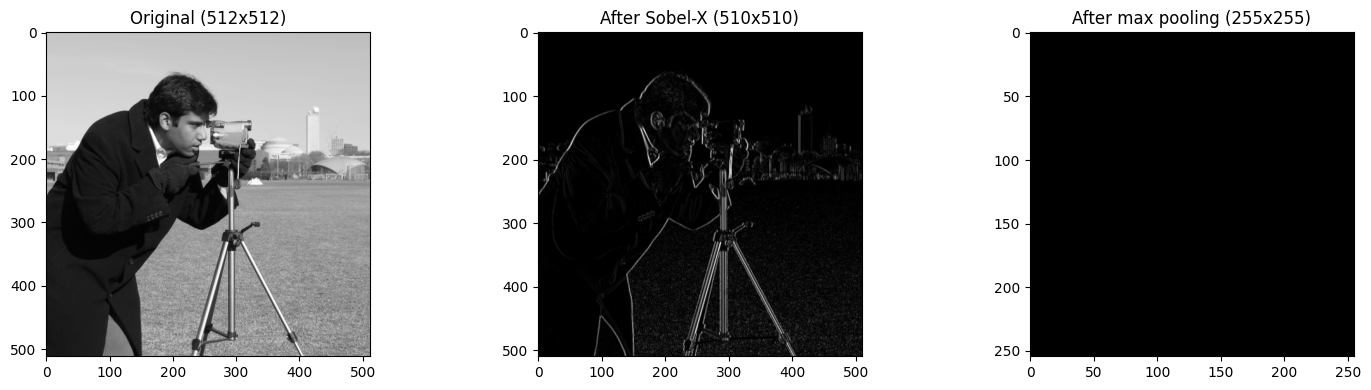

Pooling halved the dimensions: (510, 510) -> (255, 255)


In [16]:
# ⚠️ WARNING: If you run this cell before implementing max_pool2d above,
# the third panel will be ALL BLACK — that's because the function still
# returns all zeros. Come back and re-run this cell after we fill it in.

# Now apply it to a real feature map
# Let's use your convolution from yesterday on the cameraman image
from skimage import data as skdata

cam = skdata.camera().astype(np.float32)

# Apply Sobel-X to get a feature map
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)

# If you have your convolve2d from yesterday, paste it here:
# (or use this reference implementation)
def convolve2d(image, kernel):
    H, W = image.shape
    k = kernel.shape[0]
    out_h = H - k + 1
    out_w = W - k + 1
    output = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = np.sum(image[i:i+k, j:j+k] * kernel)
    return output

edge_map = convolve2d(cam, sobel_x)
pooled_edges = max_pool2d(np.abs(edge_map), pool_size=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cam, cmap='gray')
axes[0].set_title(f"Original ({cam.shape[0]}x{cam.shape[1]})")
axes[1].imshow(np.abs(edge_map), cmap='gray')
axes[1].set_title(f"After Sobel-X ({edge_map.shape[0]}x{edge_map.shape[1]})")
axes[2].imshow(pooled_edges, cmap='gray')
axes[2].set_title(f"After max pooling ({pooled_edges.shape[0]}x{pooled_edges.shape[1]})")
plt.tight_layout()
plt.show()

print(f"Pooling halved the dimensions: {edge_map.shape} -> {pooled_edges.shape}")

### ✏️ Think–Pair–Share

Look at the pooled edge map compared to the original edge map:

1. Did we lose important edge information, or are the edges mostly preserved?
2. What kind of information *did* we lose? Is that a problem for classification?
3. If we applied 2×2 max pooling twice (to a 512×512 image), what size would we end up with?

---

**🔄 Switch driver/navigator here.**

---

## Part 3: Using `nn.Conv2d`

Now let's see PyTorch's convolution layer. It does exactly what your from-scratch code does — but it's fast, differentiable, and handles batches, multiple channels, and multiple filters automatically.

### 3.1 A single Conv2d layer

In [17]:
# Create a Conv2d layer: 1 input channel (grayscale), 8 output filters, 3x3 kernel
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)

# Look at the learnable parameters
print(f"Weight shape: {conv.weight.shape}")
print(f"  -> {conv.weight.shape[0]} filters, each {conv.weight.shape[1]}x{conv.weight.shape[2]}x{conv.weight.shape[3]}")
print(f"Bias shape: {conv.bias.shape}")
print(f"Total parameters: {sum(p.numel() for p in conv.parameters())}")

Weight shape: torch.Size([8, 1, 3, 3])
  -> 8 filters, each 1x3x3
Bias shape: torch.Size([8])
Total parameters: 80


### 3.2 Apply it to the cameraman image and visualize the feature maps

The filter weights are randomly initialized, so each filter will detect "something" — but since they're not trained yet, the features won't be meaningful. Still, we can see the structure.

Input shape: torch.Size([1, 1, 512, 512])
Output shape: torch.Size([1, 8, 512, 512])
  -> 1 batch, 8 feature maps, 512x512


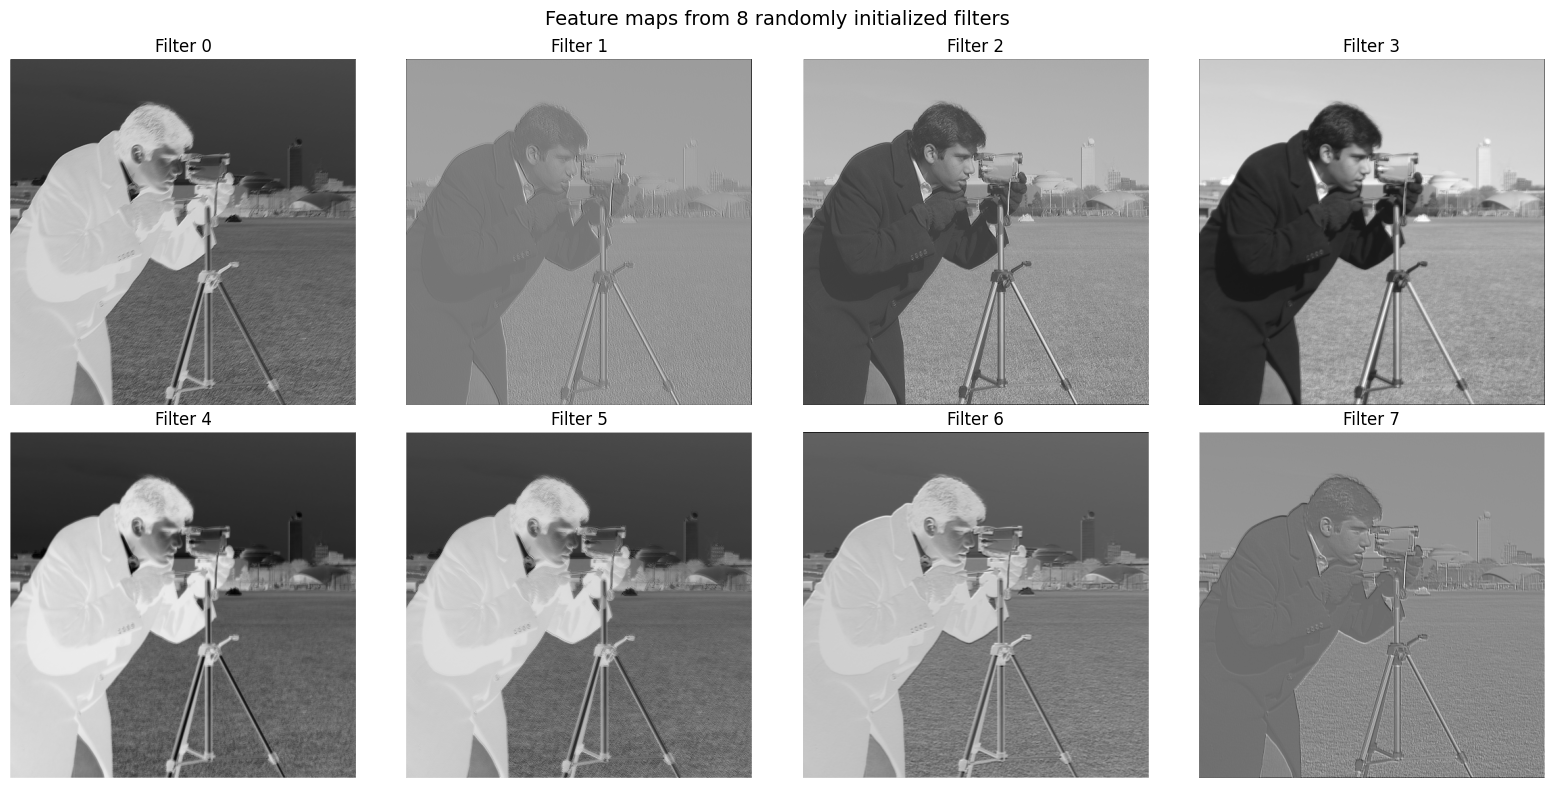

In [18]:
# Prepare the cameraman image for Conv2d
# Conv2d expects shape: (batch, channels, H, W)
cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0) / 255.0
print(f"Input shape: {cam_tensor.shape}")

# Apply the convolution (no gradient needed — just visualizing)
with torch.no_grad():
    feature_maps = conv(cam_tensor)

print(f"Output shape: {feature_maps.shape}")
print(f"  -> 1 batch, {feature_maps.shape[1]} feature maps, {feature_maps.shape[2]}x{feature_maps.shape[3]}")

# Visualize all 8 feature maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    ax = axes[i // 4, i % 4]
    ax.imshow(feature_maps[0, i].numpy(), cmap='gray')
    ax.set_title(f"Filter {i}")
    ax.axis('off')

plt.suptitle("Feature maps from 8 randomly initialized filters", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Manually setting kernel weights

Let's prove that `nn.Conv2d` is doing the same thing as your from-scratch convolution by loading a Sobel kernel into it.

Output shape: torch.Size([1, 2, 510, 510])


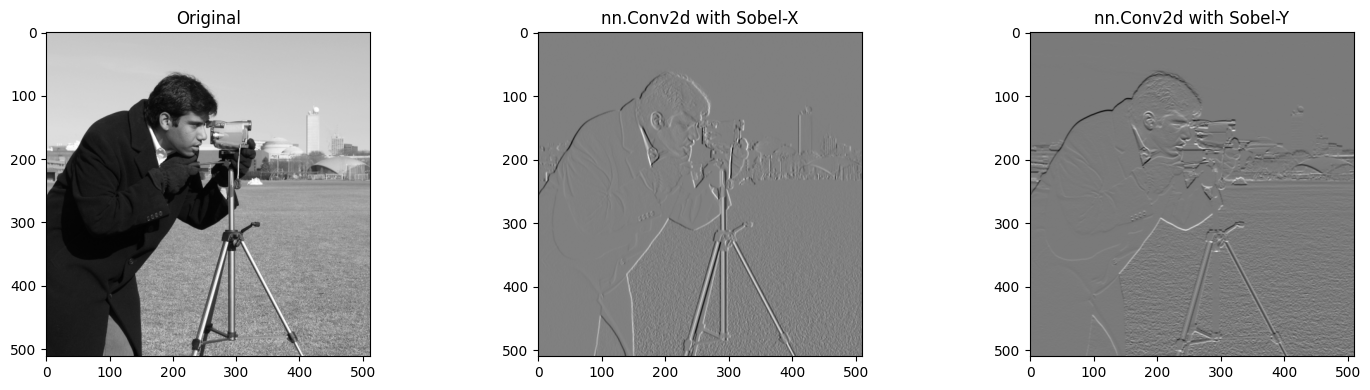

This is the SAME operation you coded yesterday — just wrapped in a PyTorch layer!


In [19]:
# Create a conv layer with 1 input channel, 2 output filters (Sobel-X and Sobel-Y)
sobel_conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, padding=0, bias=False)

# Manually set the weights to Sobel operators
sobel_x_kernel = torch.tensor([[-1., 0., 1.],
                                [-2., 0., 2.],
                                [-1., 0., 1.]])
sobel_y_kernel = torch.tensor([[-1., -2., -1.],
                                [ 0.,  0.,  0.],
                                [ 1.,  2.,  1.]])

# Weight shape must be (out_channels, in_channels, kH, kW)
with torch.no_grad():
    sobel_conv.weight[0, 0] = sobel_x_kernel
    sobel_conv.weight[1, 0] = sobel_y_kernel

# Apply to cameraman
with torch.no_grad():
    sobel_output = sobel_conv(cam_tensor)

print(f"Output shape: {sobel_output.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cam, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(sobel_output[0, 0].numpy(), cmap='gray')
axes[1].set_title("nn.Conv2d with Sobel-X")
axes[2].imshow(sobel_output[0, 1].numpy(), cmap='gray')
axes[2].set_title("nn.Conv2d with Sobel-Y")
plt.tight_layout()
plt.show()

print("This is the SAME operation you coded yesterday — just wrapped in a PyTorch layer!")

## Part 4: Building a CNN with `nn.Module`

Now let's put it all together into a complete CNN architecture. This should feel familiar from Lab 4 — you're defining `__init__` and `forward`, just with different layer types.

### 4.1 A CNN for MNIST-style images

We'll build a network that could classify 28×28 grayscale images into 10 classes. (We'll actually train it on MNIST in the next assignment.)

In [20]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Pooling layer (no learnable parameters)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Activation
        self.relu = nn.ReLU()

        # Fully connected layers
        # After 2 rounds of conv+pool on 28x28: 28 -> 14 -> 7
        # With 32 channels: 32 * 7 * 7 = 1568 features
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)

        # Conv block 1: conv -> relu -> pool
        x = self.pool(self.relu(self.conv1(x)))
        # Shape after: (batch, 16, 14, 14)

        # Conv block 2: conv -> relu -> pool
        x = self.pool(self.relu(self.conv2(x)))
        # Shape after: (batch, 32, 7, 7)

        # Flatten: merge spatial and channel dims
        x = x.view(x.size(0), -1)
        # Shape after: (batch, 1568)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        # Shape after: (batch, 128)

        x = self.fc2(x)
        # Shape after: (batch, 10) -- raw logits, no softmax!

        return x

In [21]:
# Instantiate and inspect the model
model = SimpleCNN()
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print()

# Break it down by layer
for name, param in model.named_parameters():
    print(f"{name:20s} shape: {str(list(param.shape)):20s} params: {param.numel():>8,}")

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 206,922

conv1.weight         shape: [16, 1, 3, 3]        params:      144
conv1.bias           shape: [16]                 params:       16
conv2.weight         shape: [32, 16, 3, 3]       params:    4,608
conv2.bias           shape: [32]                 params:       32
fc1.weight           shape: [128, 1568]          params:  200,704
fc1.bias             shape: [128]                params:      128
fc2.weight           shape: [10, 128]            params:    1,280
fc2.bias             shape: [10]                 params:       10


### ✏️ Reflection: Parameter Count

Look at the parameter breakdown above.

1. Which layer has the most parameters? Why?
2. How does the total compare to a fully connected network on the same input? (Hint: a FC first layer on a 28×28 image with 128 neurons would have $784 \times 128 = 100{,}352$ parameters — just for ONE layer.)
3. This is the **parameter sharing** advantage of CNNs that LeCun et al. describe. Each filter's weights are shared across all spatial positions.

---

## Part 5: Trace the Shapes

The most important CNN debugging skill is being able to predict the tensor shape at every point in the network. Let's verify.

### 5.1 Manual shape tracing

For the `SimpleCNN` above with an input batch of 4 images, each 1×28×28:

In [22]:
# Create a dummy batch: 4 grayscale 28x28 images
dummy_input = torch.randn(4, 1, 28, 28)
print(f"Input: {dummy_input.shape}")

# Trace through the network step by step
x = dummy_input

x = model.conv1(x)
print(f"After conv1 (1->16, 3x3, pad=1): {x.shape}")

x = model.relu(x)
print(f"After ReLU: {x.shape}")

x = model.pool(x)
print(f"After MaxPool2d(2): {x.shape}")

x = model.conv2(x)
print(f"After conv2 (16->32, 3x3, pad=1): {x.shape}")

x = model.relu(x)
print(f"After ReLU: {x.shape}")

x = model.pool(x)
print(f"After MaxPool2d(2): {x.shape}")

x = x.view(x.size(0), -1)
print(f"After flatten: {x.shape}")

x = model.relu(model.fc1(x))
print(f"After fc1 + ReLU: {x.shape}")

x = model.fc2(x)
print(f"After fc2 (output): {x.shape}")

Input: torch.Size([4, 1, 28, 28])
After conv1 (1->16, 3x3, pad=1): torch.Size([4, 16, 28, 28])
After ReLU: torch.Size([4, 16, 28, 28])
After MaxPool2d(2): torch.Size([4, 16, 14, 14])
After conv2 (16->32, 3x3, pad=1): torch.Size([4, 32, 14, 14])
After ReLU: torch.Size([4, 32, 14, 14])
After MaxPool2d(2): torch.Size([4, 32, 7, 7])
After flatten: torch.Size([4, 1568])
After fc1 + ReLU: torch.Size([4, 128])
After fc2 (output): torch.Size([4, 10])


### 5.2 Your turn: modify the architecture

**Task:** Modify `SimpleCNN` to add a **third** convolutional block (conv3 -> relu -> pool).

Before coding, answer these questions:

1. What should `in_channels` be for conv3?
2. If you choose `out_channels=64`, what is the spatial size after the third pool? (7 → ?)
3. What should the input size of `fc1` be? (compute: channels × height × width)

Then implement it and verify with a dummy input.

In [23]:
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # After 3 pool layers: 28 -> 14 -> 7 -> ?
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Test it:
deeper_model = DeeperCNN()
test_output = deeper_model(torch.randn(4, 1, 28, 28))
print(f"Output shape: {test_output.shape}")  # Should be (4, 10)

Output shape: torch.Size([4, 10])


## Part 6: Reflection & Exit Ticket

### ✏️ Answer these in your own words:

**1.** Without looking at your code, sketch the architecture of `SimpleCNN` on paper. Label each layer, its type, and the tensor shape at each point. (Take a photo and paste it here if you want.)

*Your answer:* Conv (1,16) ->Relu->pool -> Conv (16, 32)->Relu->pool -> flatten (32, 1568) -> linear (1568, 128) ->Relu->linear(128, 10) -> output (10)

**2.** A CNN with 32 filters of size 3×3 operating on a 3-channel (RGB) input has how many parameters? Show your work. (Don't forget bias.)

Assuming a similar architecture with to the SimpleCNN with 2 layers of convolution, a 512x512 image, and the same 10 output classes we would need to figure out the: 
    Conv layer size = (filter_w * filter_h * in_channels + bias)*output_channels/filter_count
    Relu and pooling do not have learnable parameters so no need to worry about them
    linear layer size = (input_size * output_units) + bias_terms


*Your answer:*  32*(3*3*3+1) + (3*3*32+1)*64 + (flatten to 64*128*128 = 1048576) ((1048576) * 32)+32 + (32*10) + 10
                
                896 + 18496 + 33554464 + 330
                 = 33,574,186 parameters

**3.** What are the three ways a CNN is fundamentally different from the MLP you built in Lab 4? Connect each to a specific advantage for image data.

*Your answer:* An MLP uses relies on linear layers to do the heavy lifting. While this can work for problems with 60 input dimensions, images are significantly larger and also more organized. For example, in a 512x512 image the pixels at (100, 423) and (101, 432) are almost always going to have some kind of impact on each other due to their proximity. Meanwhile, in a linear dataset, like the sonar data we used before, the data points in position 4 and 5 are largely assumed to be independent of each other. The first difference/ advantage is that CNNs utilize this correlation assumption in image and sound data by processing input in chunks using kernels that gradually shift along the image rather than linear layer that process all the data at once. This means that a CNN can look for the same patterns all over the image. The second advantage to CNN usage for image data is that kernels build a clearer representation through multiple layers of processing. The first layer of convolution is likely to notice small patterns like lighting differences at edges but by passing this information to another layer of convolution the second layer's weights can be trained to look for larger picture patterns like shapes. Instead of linear layers that can find relationships between individual data points, convolution can find relationships in an entire image. Finally, as mentioned before CNNs utilize local connections to kernels which then pass over an image instead of following the MLPs fully connected layer strategy. This is especially important for image processing due to the size of the input as well as the use of color channels. A fully connected image layer would be massively redundant and very expensive to train. Not to mention the cost is tripled with RGB channels. CNNs only have to update a small kernel instead of a network scaled to the size of the image.

**4.** In the LeCun paper, the authors describe a hierarchy: edges → textures → parts → objects. We've seen that convolution detects edges. How does *stacking* conv layers (with pooling between them) build up to detecting more complex patterns?

*Your answer:* If the first layer detects edges in an image then the next layer gets passed an image with the edges already marked out. This allows sequential layers to look for more complex patterns like shapes. From shapes the network can start combining shapes into objects, objects into scenes, and so on. By building sequential layers of convolution a CNN builds levels of detail upon itself which it then uses to found futher assumptions and processes. 

---

### Coming Next: MNIST Classifier

In the next assignment, you'll train `SimpleCNN` (or your own improved version) on the MNIST handwritten digit dataset. You'll:
- Load and preprocess MNIST using `torchvision`
- Train with cross-entropy loss and an optimizer
- Evaluate accuracy on a held-out test set
- Visualize what the learned filters actually look like
- Experiment with architecture choices and log results to MLflow

The training loop will be almost identical to what you wrote in Lab 4 — the only difference is the model architecture!